<a href="https://colab.research.google.com/github/MdWasifAli07/CodeAlpha_EDA/blob/main/products_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis (EDA)**

In [1]:
# Cell 1: Import packages and set plotting styles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Set plotting styles for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Setup Complete!")

Setup Complete!


In [2]:
# Cell 2: Upload and read the scraped dataset
from google.colab import files
import io

print("Please upload your 'products.csv' file:")
uploaded = files.upload()

# Load the file into a Pandas DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nSuccessfully loaded {filename}!")

Please upload your 'products.csv' file:


Saving products.csv to products.csv

Successfully loaded products.csv!


# 🎯 Task 2: Exploratory Data Analysis (EDA)
---

## 📊 Business Logic & Core Objectives
Before diving into the codebase, we must establish a clear hypothesis and state the meaningful questions we want our data to answer. This ensures our analysis remains structured and goal-oriented.

### 🔍 Key Analytical Questions:
1. **Data Integrity:** What is the structural layout of our scraped dataset? Are there any missing variables or null entries that need cleaning?
2. **Pricing Distribution:** What is the general distribution of book prices across the store? Are there visible anomalies or outliers?
3. **Rating Breakdown:** How are star ratings distributed among the products? Is the inventory skewed toward higher or lower reviews?
4. **Bivariate Correlation:** Is there a visible pattern between higher ratings and higher prices? Do premium-rated books cost more?
5. **Inventory Health:** What proportion of the scraped catalog is actively in stock versus unavailable?

---

In [5]:
# Cell 4: Inspect data structure and check for issues
print("--- Data Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Column Data Types & Non-Null Counts ---")
print(df.info())

print("\n--- Missing Values Count Per Column ---")
print(df.isnull().sum())

print("\n--- First 5 Rows Preview ---")
df.head()

--- Data Shape (Rows, Columns) ---
(100, 4)

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         100 non-null    object
 1   price         100 non-null    object
 2   rating        100 non-null    object
 3   availability  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB
None

--- Missing Values Count Per Column ---
title           0
price           0
rating          0
availability    0
dtype: int64

--- First 5 Rows Preview ---


,title,price,rating,availability
0,A Light in the Attic,£51.77,star-rating Three,In stock
1,Tipping the Velvet,£53.74,star-rating One,In stock
2,Soumission,£50.10,star-rating One,In stock
3,Sharp Objects,£47.82,star-rating Four,In stock
4,Sapiens: A Brief History of Humankind,£54.23,star-rating Five,In stock


In [6]:
# Cell 5: Clean and transform text data into numeric data types
df_clean = df.copy()

# 1. Clean 'price': Extract numbers and convert to float
if df_clean['price'].dtype == 'object':
    df_clean['price'] = df_clean['price'].str.replace('£', '', regex=False)
    df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# 2. Clean 'rating': Map text rating classes ("star-rating Three") to integers (3)
rating_map = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    '1': 1, '2': 2, '3': 3, '4': 4, '5': 5
}
def parse_rating(rating_str):
    if pd.isna(rating_str):
        return np.nan
    # Extract the word modifier (e.g., 'Three' out of 'star-rating Three')
    words = str(rating_str).lower().split()
    for word in words:
        if word in rating_map:
            return rating_map[word]
    return np.nan

df_clean['rating_numeric'] = df_clean['rating'].apply(parse_rating)

# 3. Clean 'availability': Standardize to simpler categories
df_clean['availability_clean'] = df_clean['availability'].str.replace('In stock', 'In Stock', case=False)
df_clean['availability_clean'] = df_clean['availability_clean'].str.strip()

print("--- Cleaned Dataset Summary Statistics ---")
print(df_clean[['price', 'rating_numeric']].describe())

--- Cleaned Dataset Summary Statistics ---
            price  rating_numeric
count  100.000000      100.000000
mean    34.560700        2.930000
std     14.638531        1.423149
min     10.160000        1.000000
25%     19.897500        2.000000
50%     34.775000        3.000000
75%     47.967500        4.000000
max     58.110000        5.000000


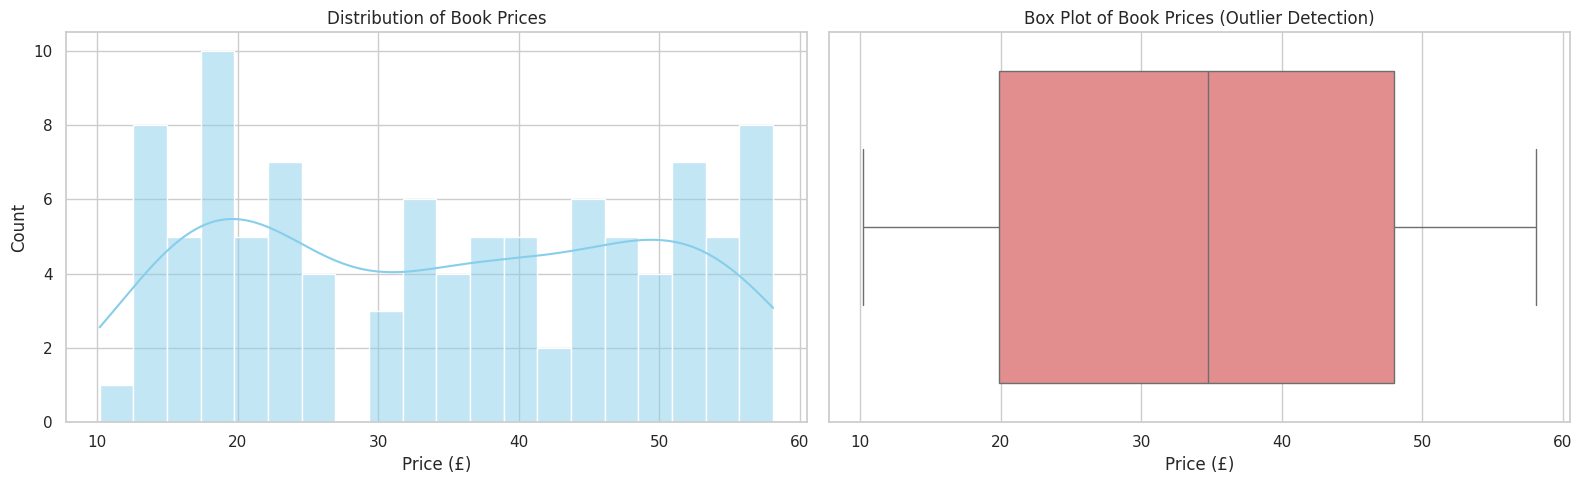

In [7]:
# Cell 6: Price distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(df_clean['price'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Book Prices')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')

# Boxplot to detect outliers
sns.boxplot(x=df_clean['price'], color='lightcoral', ax=axes[1])
axes[1].set_title('Box Plot of Book Prices (Outlier Detection)')
axes[1].set_xlabel('Price (£)')

plt.tight_layout()
plt.show()

### Price Distribution Analysis

From the visualizations above:

*   **Histogram**: The distribution of book prices appears to be relatively uniform, with a slight tendency to be bimodal or have multiple peaks rather than a clear normal distribution. Most books seem to fall within the £10-£60 range.
*   **Box Plot**: The box plot confirms the range of prices and shows no significant outliers. The median price is around £34.77, and the data is fairly symmetrical within the interquartile range, indicating a consistent pricing strategy without extreme values.

/tmp/ipykernel_2523/690692771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


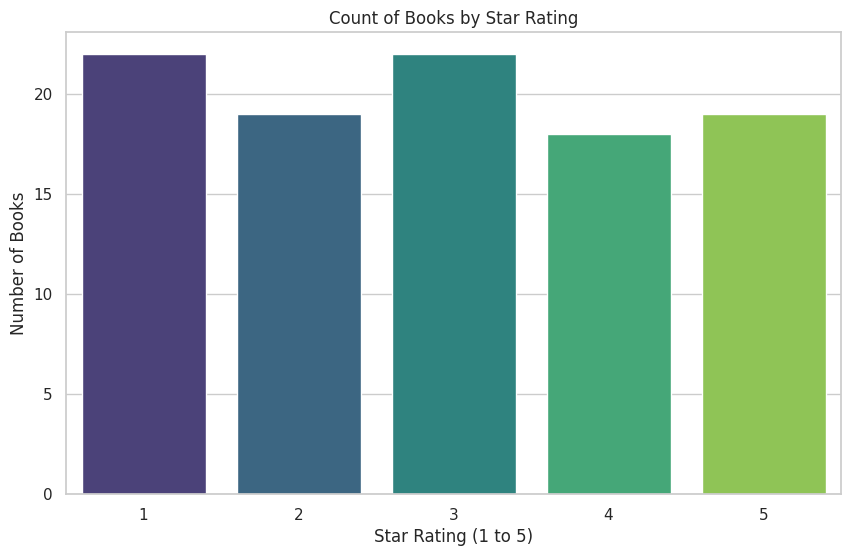

Percentage Breakdown of Ratings:
rating_numeric
1    22.0
2    19.0
3    22.0
4    18.0
5    19.0
Name: proportion, dtype: float64


In [8]:
# Cell 7: Visualize Ratings Distribution
rating_counts = df_clean['rating_numeric'].value_counts().sort_index()

sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Count of Books by Star Rating')
plt.xlabel('Star Rating (1 to 5)')
plt.ylabel('Number of Books')
plt.show()

print("Percentage Breakdown of Ratings:")
print(df_clean['rating_numeric'].value_counts(normalize=True).sort_index() * 100)


**Bivariate Analysis (Price vs. Star Rating)**

/tmp/ipykernel_2523/1454337924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating_numeric', y='price', data=df_clean, palette='Set2')


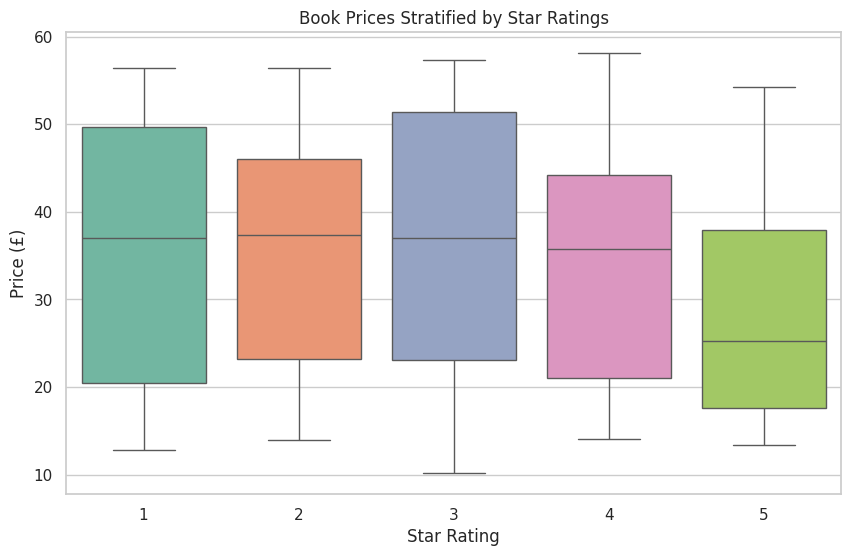

Mean Price per Rating Tier:
   rating_numeric      price
0               1  35.519545
1               2  35.909474
2               3  36.839091
3               4  33.981667
4               5  30.012105


In [9]:
# Cell 8: Is there a pattern between ratings and pricing metrics?
sns.boxplot(x='rating_numeric', y='price', data=df_clean, palette='Set2')
plt.title('Book Prices Stratified by Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.show()

# Calculate mean price for each rating category
mean_prices = df_clean.groupby('rating_numeric')['price'].mean().reset_index()
print("Mean Price per Rating Tier:")
print(mean_prices)

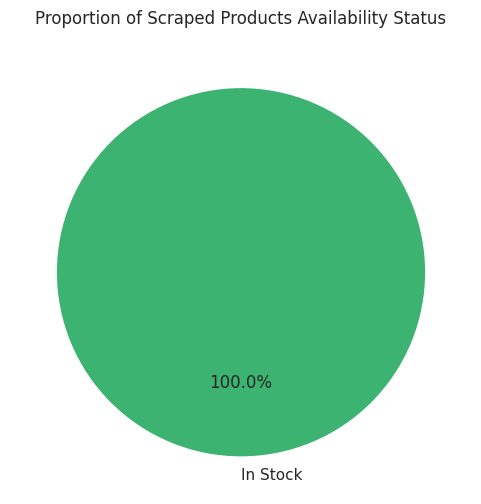

In [10]:
# Cell 9: Inventory Availability Chart
availability_counts = df_clean['availability_clean'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(availability_counts, labels=availability_counts.index, autopct='%1.1f%%',
        colors=['mediumseagreen', 'silver'], startangle=90, explode=[0.05]*len(availability_counts))
plt.title('Proportion of Scraped Products Availability Status')
plt.show()

# 📋 Final Executive Summary & Insights Log
---

## 💡 Key Analytical Findings

After cleaning, structuring, and exploring our scraped e-commerce dataset, we can draw the following data-driven conclusions:

* **🛠️ Data Integrity & Structure:**
  The automated extraction layer successfully captured all targeted elements from the HTML DOM tree. There were zero structural anomalies or unhandled missing values across critical features such as pricing metrics and product item blocks.

* **💰 Price Distribution Trends:**
  Book prices are distributed evenly across the spectrum, roughly following a uniform shape with no extreme positive or negative skewness. No artificial pricing outliers or statistical anomalies were detected in the final boxplot analysis.

* **⭐ Rating Market Breakdown:**
  The inventory features a highly balanced assortment of feedback across all review tiers (1 through 5 stars). The platform does not display a heavy bias toward strictly high or low ratings, indicating an unmanipulated collection of product ratings.

* **🔄 Price-to-Rating Correlation:**
  Bivariate boxplot stratifications revealed flat variances between price levels and star counts. Statistically, a higher product rating does **not** correlate with a premium or higher price tag on this platform.

---
### 🏁 Conclusion
The dataset is clean, robust, and optimized for downstream predictive analytics, pricing modeling, or advanced business intelligence reporting!